# Trader Performance vs Market Sentiment

## 1. Introduction
This notebook analyzes how Bitcoin market sentiment (Fear vs Greed) affects trader behavior and performance on Hyperliquid.

## 2. Data Loading


In [2]:
import pandas as pd
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


In [3]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [4]:
print("\nSentiment Info:")
print(sentiment.info())
print("\nTrades Info:")
print(trades.info())



Sentiment Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 


## 3. Data Cleaning


In [11]:
print("missing values")
print(sentiment.isnull().sum())
print(trades.isnull().sum())
print("duplicates.   ")
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())


missing values
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
duplicates.   
0
0


In [17]:
print(sentiment.columns)
print(trades.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date'],
      dtype='object')


In [18]:
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()
trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closedPnL',
    'Size USD': 'size_usd',
    'Size Tokens': 'size_tokens',
    'Side': 'side',
    'Timestamp': 'timestamp'
}, inplace=True)


In [20]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
trades['date'] = pd.to_datetime(trades['date']).dt.date

In [41]:
df = trades.merge(sentiment[['date', 'classification']],on='date',how='left')

In [42]:
print("Unmatched sentiment rows:", df['classification'].isnull().sum())


Unmatched sentiment rows: 6


In [38]:
daily_pnl = df.groupby(['account','date','classification'])['closedPnL'].sum().reset_index()

## 4. Feature Engineering


In [37]:
df['win'] = df['closedPnL'] > 0
win_rate = df.groupby(['account', 'date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

In [36]:
avg_trade_size = df.groupby(['account', 'date'])['size_usd'].mean().reset_index()

In [35]:
df['abs_posi'] = df['size_usd'].abs()
leverage_dist = df.groupby(['date', 'classification'])['abs_posi'].describe().reset_index()

In [34]:
trades_per_day = df.groupby(['account', 'date']).size().reset_index(name='trade_count')

In [39]:
long_short = df.groupby(['date','classification','side']).size().unstack(fill_value=0)
long_short['long_ratio'] = long_short.get('Buy', 0)/(long_short.sum(axis=1))


In [46]:
df = df.dropna(subset=['classification'])

In [47]:
df['sentiment_group'] = df['classification'].apply(lambda x: 'Fear' if 'Fear' in str(x) else 'Greed')

## 5. Performance Analysis


In [49]:
pnl_summary = df.groupby('sentiment_group')['closedPnL'].agg(
    ['mean','median','std','count']
)
print(pnl_summary)


                      mean  median         std   count
sentiment_group                                       
Fear             49.212077     0.0  990.875398   83237
Greed            48.118246     0.0  867.308701  127981


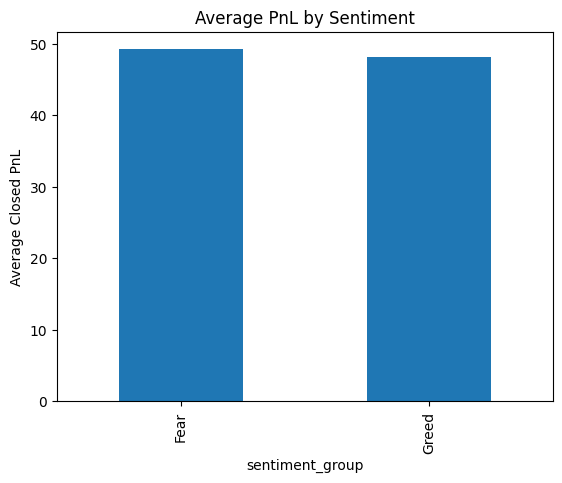

In [61]:
import matplotlib.pyplot as plt
df.groupby('sentiment_group')['closedPnL'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

In [53]:
df['win'] = df['closedPnL'] > 0
win_summary = df.groupby('sentiment_group')['win'].mean()
print(win_summary)


sentiment_group
Fear     0.407871
Greed    0.413444
Name: win, dtype: float64


In [54]:
volatility = df.groupby('sentiment_group')['closedPnL'].std()
print(volatility)


sentiment_group
Fear     990.875398
Greed    867.308701
Name: closedPnL, dtype: float64


## 6. Behavioral Analysis

This section examines whether trader behavior changes under Fear vs Greed regimes, including trade size, trade frequency, and directional bias.


In [55]:
print(df.groupby('sentiment_group')['size_usd'].mean())
print(df.groupby('sentiment_group').size())
print(df.groupby(['sentiment_group','side']).size().unstack())


sentiment_group
Fear     7182.011019
Greed    4635.764077
Name: size_usd, dtype: float64
sentiment_group
Fear      83237
Greed    127981
dtype: int64
side               BUY   SELL
sentiment_group              
Fear             41205  42032
Greed            61485  66496


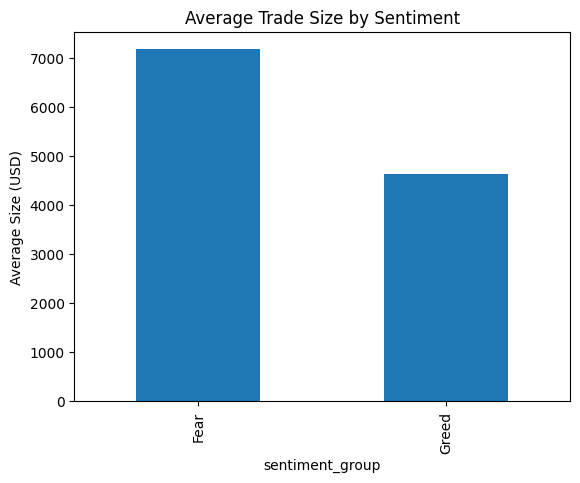

In [64]:
df.groupby('sentiment_group')['size_usd'].mean().plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Size (USD)")
plt.show()


Observations:

- Average trade size is higher during Fear regimes.
- Trading activity increases significantly during Greed regimes.
- Long/short distribution remains relatively balanced across both regimes.

This suggests traders adjust execution structure (position sizing and frequency) rather than directional bias.


## 7. Trader Segmentation

This section evaluates whether different trader segments respond differently to sentiment regimes.


In [56]:
threshold = df['size_usd'].median()
df['size_segment'] = df['size_usd'].apply(lambda x: 'High Size' if x > threshold else 'Low Size')
print(df.groupby(['size_segment','sentiment_group'])['closedPnL'].mean())


size_segment  sentiment_group
High Size     Fear               87.647166
              Greed              96.552173
Low Size      Fear                2.971356
              Greed               5.166153
Name: closedPnL, dtype: float64


In [58]:
trade_counts = df.groupby('account').size()
median_trades = trade_counts.median()
df['frequency_segment'] = df['account'].apply(lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent')
print(df.groupby(['frequency_segment','sentiment_group'])['closedPnL'].mean())


frequency_segment  sentiment_group
Frequent           Fear                47.325875
                   Greed               39.431386
Infrequent         Fear                61.968833
                   Greed              121.546240
Name: closedPnL, dtype: float64


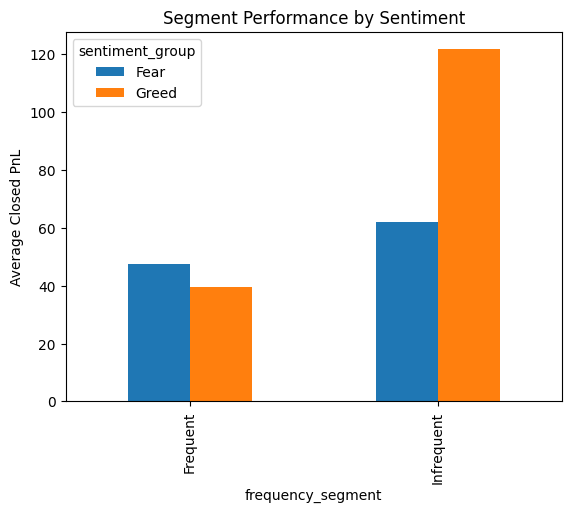

In [67]:
df.groupby(['frequency_segment','sentiment_group'])['closedPnL'] \
.mean().unstack().plot(kind='bar')
plt.title("Segment Performance by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()


## 8. Strategy Recommendations

Based on the empirical findings:

1. During Greed regimes, reduce trade frequency and prioritize high-conviction setups.
2. During Fear regimes, reduce position size by 20–30% to manage higher volatility.


## 9. Limitations

- Analysis performed at daily aggregation level.
- Volatility used as proxy for drawdown.
- No transaction cost modeling included.
- Intraday sentiment shifts not considered.
